# Reconstrution operators

In [ ]:
%%capture
# Install deepinv
!pip install git+https://github.com/deepinv/deepinv.git

In [ ]:
import torch
import deepinv as dinv
import matplotlib.pyplot as plt
from deepinv.optim.prior import Prior
from deepinv.utils import load_url_image, get_image_url

torch.manual_seed(0)

In [ ]:
device = dinv.utils.get_freer_gpu() if torch.cuda.is_available() else "cpu"
PSNR_metric = dinv.loss.metric.PSNR()
SSIM_metric = dinv.loss.metric.SSIM()

Selected GPU 0 with 15092 MiB free memory 


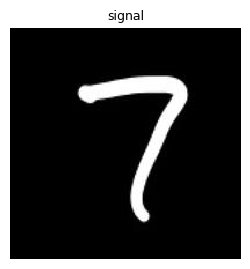

In [ ]:
# url = ("https://i.sstatic.net/fyPhv.jpg")
# img_size = 280
# x_mnist = load_url_image(url=url, img_size=img_size, grayscale=True, device=device)

# uncommend this if the first image does not load
url = ("https://transform.roboflow.com/L95p2LSggHQXqr9B82yukxbilkC2/c5eb4417a99b20493ed9c00da2318b39/thumb.jpg")
img_size = 200
x_mnist = load_url_image(url=url, img_size=img_size, grayscale=True, device=device)

x_mnist = 1 - x_mnist

dinv.utils.plot([x_mnist], ["signal"], figsize=(3,3))

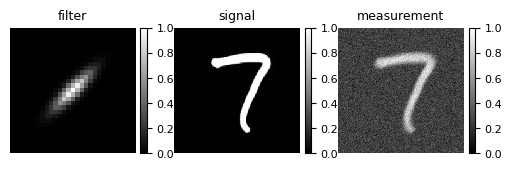

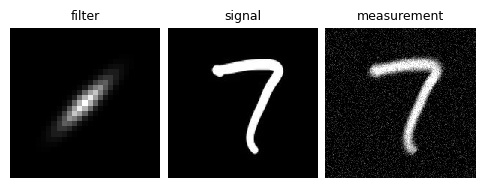

In [ ]:
noise_model=dinv.physics.GaussianNoise(sigma=0.1)
filter = dinv.physics.blur.gaussian_blur(sigma=(1, 4), angle=45)
physics = dinv.physics.BlurFFT(filter=filter, img_size=(1, img_size, img_size),\
                            noise_model=noise_model,\
                                device=device)

y = physics(x_mnist)
dinv.utils.plot([filter, x_mnist, y], ["filter","signal", "measurement"], cbar=True)
dinv.utils.plot([filter, x_mnist, y], ["filter","signal", "measurement"], rescale_mode='clip')


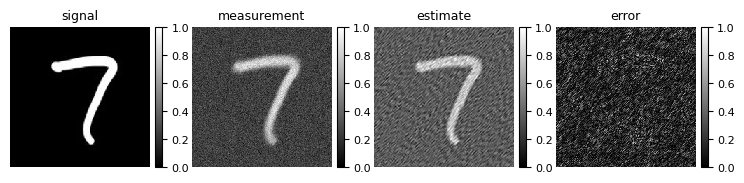

PSNR: 14.86269760131836
SSIM: 0.05840864032506943


In [ ]:
data_fidelity = dinv.optim.data_fidelity.L2()
prior = dinv.optim.prior.Zero()

rec_model = dinv.optim.optim_builder(iteration="PGD", prior=prior, data_fidelity=data_fidelity, \
                                 max_iter=100, crit_conv='residual', thres_conv=1e-4, early_stop=True, \
                                 params_algo={"stepsize": 1.0, "lambda": 3e-2})
x_hat = rec_model(y, physics)
error = torch.abs(x_hat-x_mnist)
dinv.utils.plot([x_mnist, y, x_hat, error], ["signal", "measurement", "estimate", "error"], cbar=True, figsize=(9,3))

print(f'PSNR: {PSNR_metric(x_hat,x_mnist).item()}')
print(f'SSIM: {SSIM_metric(x_hat,x_mnist).item()}')

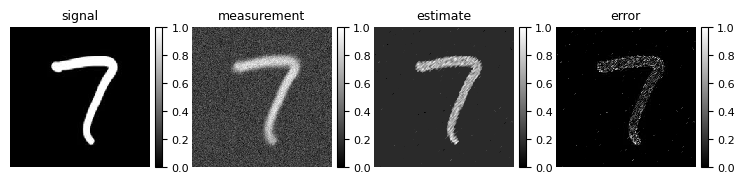

PSNR: 24.378873825073242
SSIM: 0.8923380374908447


In [ ]:
data_fidelity = dinv.optim.data_fidelity.L2()
prior = dinv.optim.prior.L1Prior()

rec_model = dinv.optim.optim_builder(iteration="PGD", prior=prior, data_fidelity=data_fidelity, \
                                 max_iter=100, crit_conv='residual', thres_conv=1e-4, early_stop=True, \
                                 params_algo={"stepsize": 1.0, "lambda": 3e-2})
x_hat = rec_model(y, physics)
error = torch.abs(x_hat-x_mnist)
dinv.utils.plot([x_mnist, y, x_hat, error], ["signal", "measurement", "estimate", "error"], cbar=True, figsize=(9,3))

print(f'PSNR: {PSNR_metric(x_hat,x_mnist).item()}')
print(f'SSIM: {SSIM_metric(x_hat,x_mnist).item()}')

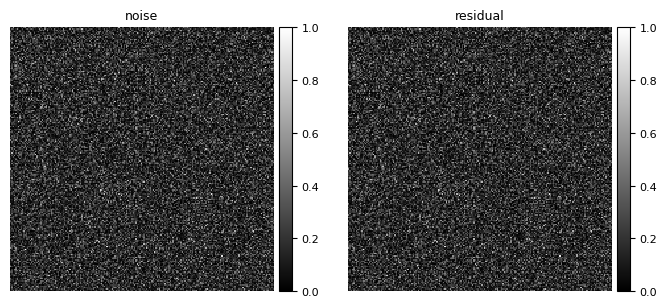

Noise norm:  19.96062660217285
Residual norm:  19.884111404418945


In [ ]:
noise = physics.A(x_mnist) - y
residual= physics.A(x_hat) - y

dinv.utils.plot([torch.abs(noise), torch.abs(residual)], ["noise", "residual"], cbar=True, figsize=(8,4))

print('Noise norm: ', noise.norm().item())
print('Residual norm: ', residual.norm().item())

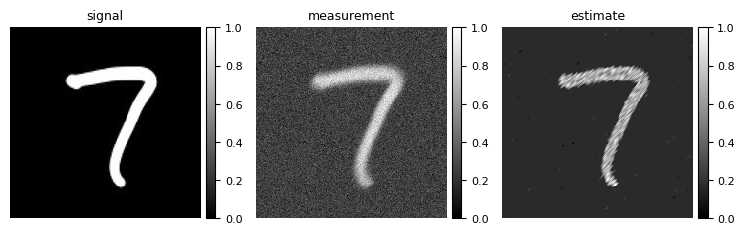

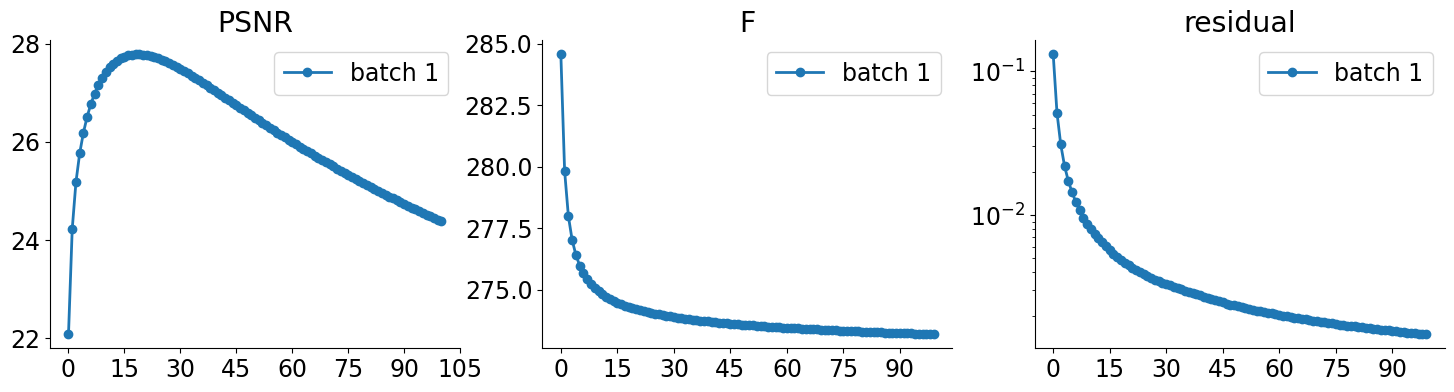

PSNR: 24.378873825073242
SSIM: 0.8923380374908447


In [ ]:
rec_model = dinv.optim.optim_builder(iteration="PGD", prior=prior, data_fidelity=data_fidelity, \
                                 max_iter=100, crit_conv='residual', thres_conv=1e-3, early_stop=True, \
                                 params_algo={"stepsize": 1.0, "lambda": 3e-2})
x_hat, metrics = rec_model(y, physics, x_gt=x_mnist, compute_metrics=True)
dinv.utils.plot([x_mnist, y, x_hat], ["signal", "measurement", "estimate"], cbar=True, figsize=(9,3))
dinv.utils.plot_curves(metrics)
print(f'PSNR: {PSNR_metric(x_hat,x_mnist).item()}')
print(f'SSIM: {SSIM_metric(x_hat,x_mnist).item()}')

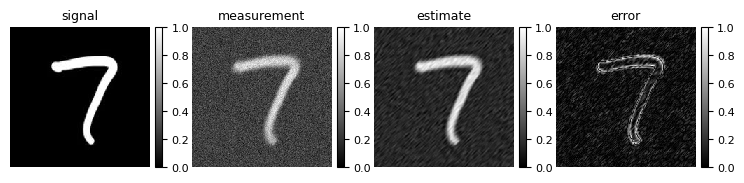

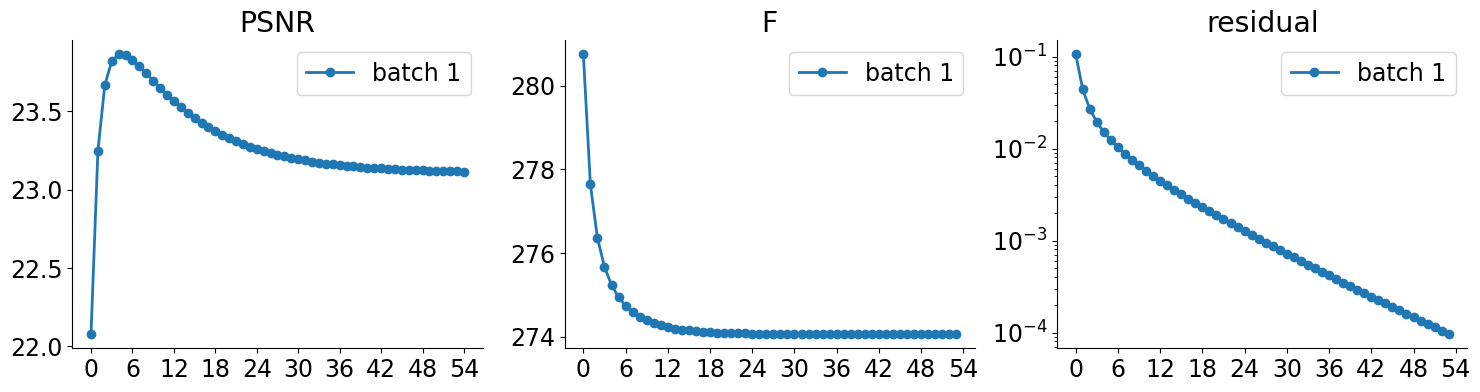

PSNR: 23.11573028564453
SSIM: 0.2100888341665268


In [ ]:
# Create a custom prior which inherits from the base Prior class.
class L2Prior(Prior):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.explicit_prior = True

    def fn(self, x, args, **kwargs):
        return 0.5 * torch.norm(x.view(x.shape[0], -1), p=2, dim=-1) ** 2

# Specify the custom prior
prior = L2Prior()

rec_model = dinv.optim.optim_builder(iteration="PGD", prior=prior, data_fidelity=data_fidelity, \
                                 max_iter=100, crit_conv='residual', thres_conv=1e-4, early_stop=True, \
                                 params_algo={"stepsize": 1.0, "lambda": 8e-2})

x_hat, metrics = rec_model(y, physics, x_gt=x_mnist, compute_metrics=True)
error = torch.abs(x_hat-x_mnist)
dinv.utils.plot([x_mnist, y, x_hat, error], ["signal", "measurement", "estimate", "error"], cbar=True, figsize=(9,3))
dinv.utils.plot_curves(metrics)

print(f'PSNR: {PSNR_metric(x_hat,x_mnist).item()}')
print(f'SSIM: {SSIM_metric(x_hat,x_mnist).item()}')

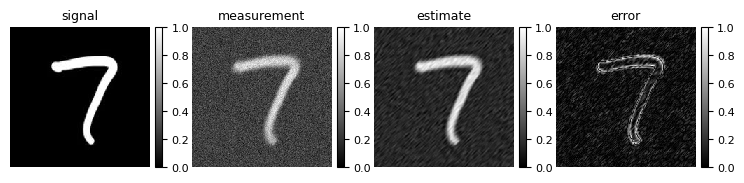

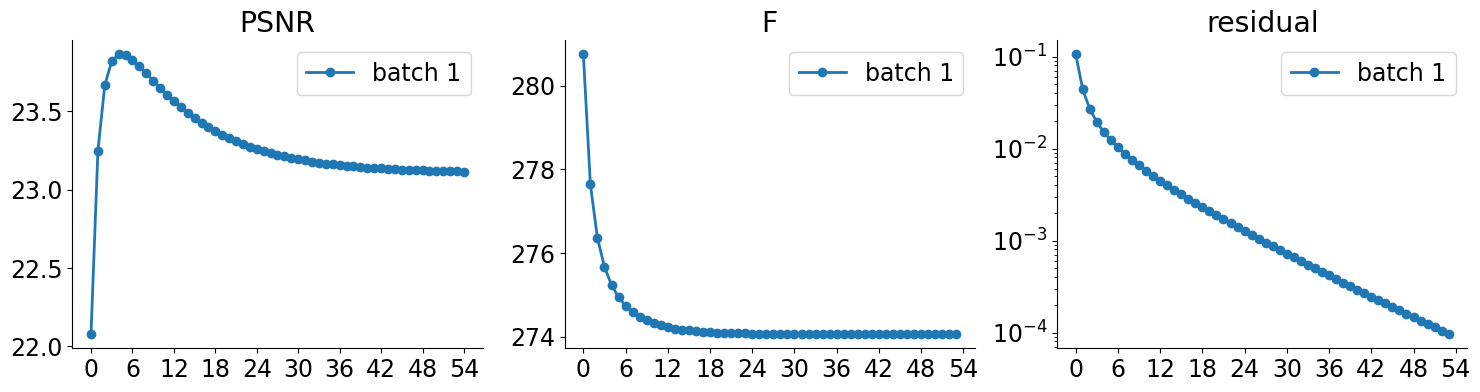

PSNR: 23.11573028564453
SSIM: 0.2100888341665268


In [ ]:
def g(x, *args, **kwargs):
    return 0.5 * torch.norm(x.view(x.shape[0], -1), p=2, dim=-1) ** 2

# Specify the custom prior
prior = Prior(g=g)

rec_model = dinv.optim.optim_builder(iteration="PGD", prior=prior, data_fidelity=data_fidelity, \
                                 max_iter=100, crit_conv='residual', thres_conv=1e-4, early_stop=True, \
                                 params_algo={"stepsize": 1.0, "lambda": 8e-2})

x_hat, metrics = rec_model(y, physics, x_gt=x_mnist, compute_metrics=True)
error = torch.abs(x_hat-x_mnist)
dinv.utils.plot([x_mnist, y, x_hat, error], ["signal", "measurement", "estimate", "error"], cbar=True, figsize=(9,3))
dinv.utils.plot_curves(metrics)

print(f'PSNR: {PSNR_metric(x_hat,x_mnist).item()}')
print(f'SSIM: {SSIM_metric(x_hat,x_mnist).item()}')

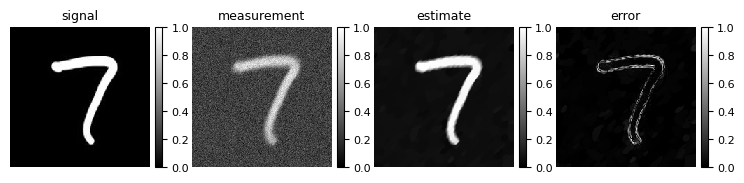

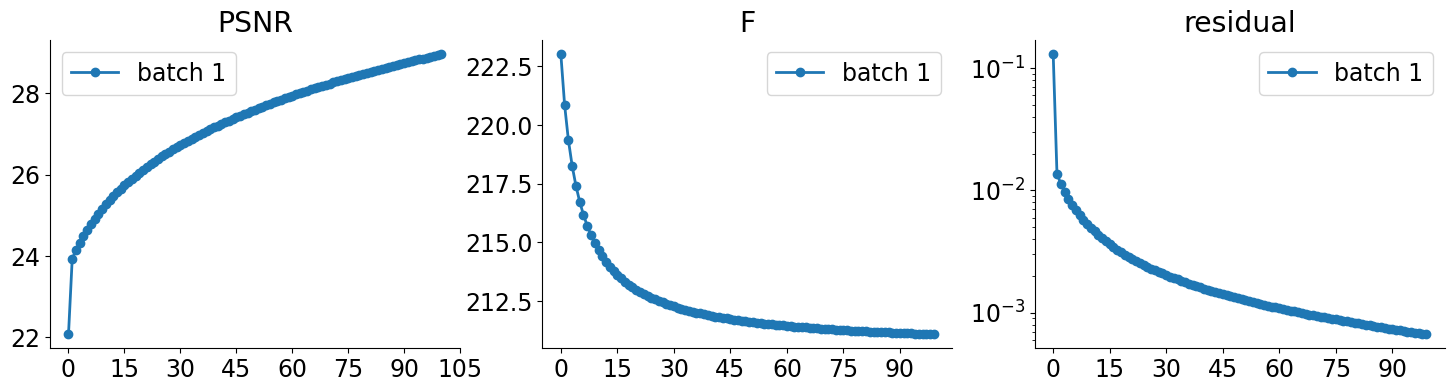

PSNR: 28.959774017333984
SSIM: 0.7503066658973694


In [ ]:
data_fidelity = dinv.optim.data_fidelity.L2()
prior = dinv.optim.prior.TVPrior(n_it_max=10)

rec_model = dinv.optim.optim_builder(iteration="PGD", prior=prior, data_fidelity=data_fidelity, \
                                 max_iter=100, crit_conv='residual', thres_conv=1e-4, early_stop=True, \
                                 params_algo={"stepsize": 1.0, "lambda": 3e-2})
x_hat, metrics = rec_model(y, physics, x_gt=x_mnist, compute_metrics=True)
error = torch.abs(x_hat-x_mnist)
dinv.utils.plot([x_mnist, y, x_hat, error], ["signal", "measurement", "estimate", "error"], cbar=True, figsize=(9,3))
dinv.utils.plot_curves(metrics)

print(f'PSNR: {PSNR_metric(x_hat,x_mnist).item()}')
print(f'SSIM: {SSIM_metric(x_hat,x_mnist).item()}')